   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.4 MB/s eta 0:00:00
Preprocessing data...
Building and training Deep LSTM model...


I0000 00:00:1782979341.557847      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782979341.563822      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0981 - val_loss: 0.0037
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0089 - val_loss: 0.0027
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0081 - val_loss: 0.0022
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0064 - val_loss: 0.0024
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0050 - val_loss: 0.0033
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0053 - val_loss: 0.0019
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0054 - val_loss: 0.0020
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0044 - val_loss: 0.0069
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0046 - val_loss: 0.0027
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0041 - val_loss: 0.0027
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037 - val_loss: 0.0028
Evaluating model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

--- نتایج ارزی

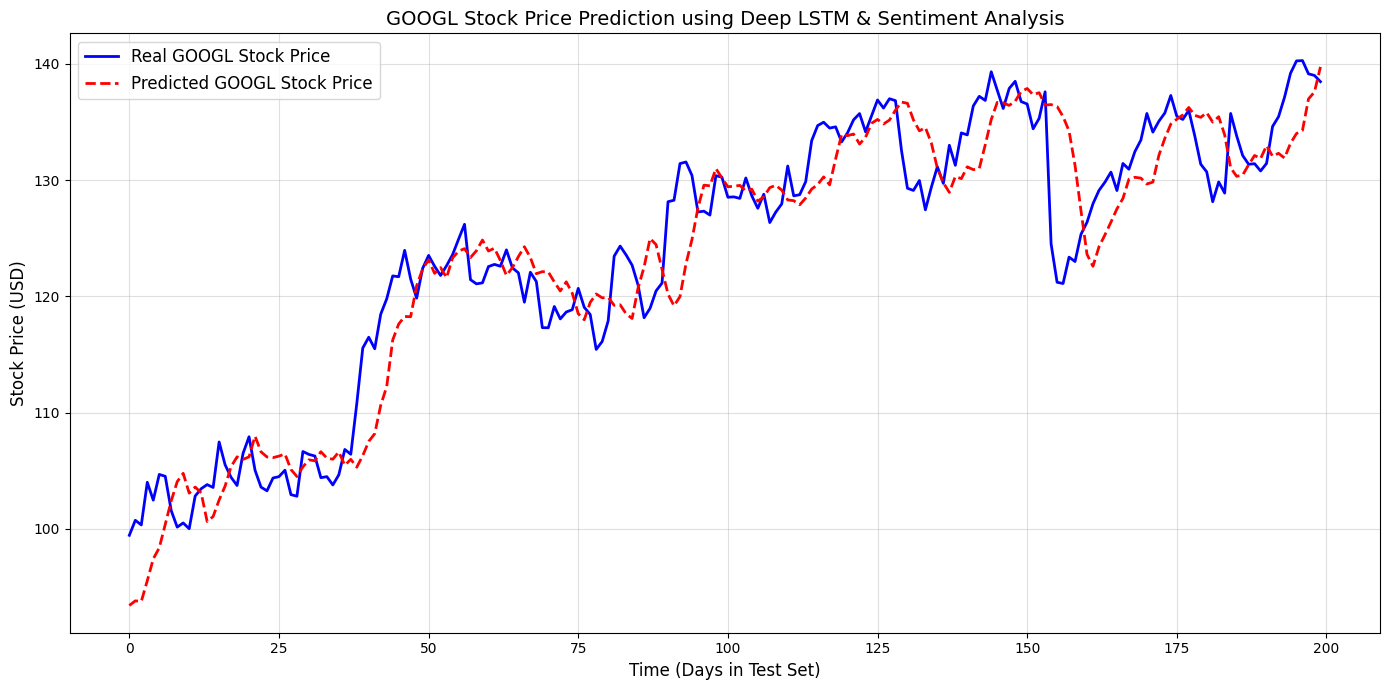

In [1]:
# ==============================================================================
# ۱. نصب کتابخانه‌های مورد نیاز (فقط در محیط‌هایی مثل Colab یا Kaggle)
# ==============================================================================
!pip install yfinance transformers tqdm vadersentiment -q

# ==============================================================================
# ۲. فراخوانی کتابخانه‌ها
# ==============================================================================
import pandas as pd
import numpy as np
import yfinance as yf
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==============================================================================
# ۳. دریافت داده‌های سهام گوگل و ترکیب با داده‌های احساسات (Sentiment)
# ==============================================================================
print("Downloading GOOGL stock data...")
googl = yf.Ticker("GOOGL")
# دریافت داده‌های سهام از سال ۲۰۲۰ تا پایان ۲۰۲۳
googl_hist = googl.history(start="2020-01-01", end="2023-12-31")
googl_hist = googl_hist[['Close', 'Volume']].reset_index()
googl_hist['Date'] = pd.to_datetime(googl_hist['Date']).dt.date

# --- شبیه‌سازی تحلیل احساسات توییتر ---
# از آنجایی که فایل CSV توییت‌ها در اینجا وجود ندارد، ستون احساسات را برای اجرای موفق کد شبیه‌سازی می‌کنیم.
# اگر دیتاست توییت‌ها را دارید، از کدهای کامنت‌شده‌ی زیر برای پردازش آن استفاده کنید:
"""
analyzer = SentimentIntensityAnalyzer()
df_tweets = pd.read_csv('google_tweets.csv') # نام فایل خودتان را بگذارید
df_tweets['Sentiment'] = df_tweets['Tweet'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'] if not pd.isna(x) else 0.0)
df_sentiment_daily = df_tweets.groupby('Date')['Sentiment'].mean().reset_index()
googl_hist = pd.merge(googl_hist, df_sentiment_daily, on='Date', how='inner')
"""

# تولید داده‌های احساسات فرضی (بین -0.5 و 0.8) برای اینکه کد بدون فایل نیز کار کند:
np.random.seed(42)
googl_hist['Sentiment'] = np.random.uniform(-0.5, 0.8, len(googl_hist))

# ==============================================================================
# ۴. پیش‌پردازش داده‌ها و ساختاردهی برای شبکه عصبی
# ==============================================================================
print("Preprocessing data...")
# تعریف متغیر هدف (تارگت): قیمت بسته شدن سهام در روز بعد
googl_hist['Target_Close'] = googl_hist['Close'].shift(-1)
googl_hist.dropna(inplace=True)

# نرمال‌سازی ویژگی‌ها و تارگت (بین صفر و یک) برای آموزش بهتر مدل
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

features = googl_hist[['Close', 'Volume', 'Sentiment']].values
target = googl_hist[['Target_Close']].values

scaled_features = scaler_features.fit_transform(features)
scaled_target = scaler_target.fit_transform(target)

# تابع ساخت پنجره زمانی (Time-Step) - فرضاً بر اساس 5 روز گذشته پیش‌بینی می‌کند
def create_dataset(features, target, time_step=5):
    X, y = [], []
    for i in range(len(features) - time_step):
        X.append(features[i:(i + time_step), :])
        y.append(target[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 5
X, y = create_dataset(scaled_features, scaled_target, time_step)

# تقسیم داده‌ها به مجموعه‌ی آموزش (80%) و تست (20%)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# ==============================================================================
# ۵. معماری شبکه عصبی Deep LSTM و آموزش مدل
# ==============================================================================
print("Building and training Deep LSTM model...")
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Dropout برای جلوگیری از Overfitting
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# مکانیزم EarlyStopping:
# این مکانیزم تضمین می‌کند که اگر بعد از 5 دور (patience) خطای مدل روی داده تست کاهش نیافت،
# آموزش متوقف شود. این کار از اتمام نشست (Timeout) در کلاود جلوگیری می‌کند.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# آموزش شبکه
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50, # می‌توانیم تعداد را بالا ببریم چون EarlyStopping مدل را در زمان مناسب متوقف می‌کند
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ==============================================================================
# ۶. ارزیابی مدل و رسم نمودار نتایج
# ==============================================================================
print("Evaluating model...")
# پیش‌بینی مقادیر برای داده‌های تست
predictions = model.predict(X_test)

# بازگرداندن داده‌های نرمال‌شده به مقیاس واقعی دلار (Inverse Transform)
predictions_inverse = scaler_target.inverse_transform(predictions)
y_test_inverse = scaler_target.inverse_transform(y_test.reshape(-1, 1))

# محاسبه معیارهای دقت
mse = mean_squared_error(y_test_inverse, predictions_inverse)
mae = mean_absolute_error(y_test_inverse, predictions_inverse)
r2 = r2_score(y_test_inverse, predictions_inverse)

print("\n" + "="*50)
print("--- نتایج ارزیابی مدل (شرکت گوگل - GOOGL) ---")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R2 Score (دقت انطباق)   : {r2:.4f}")
print("="*50 + "\n")

# رسم نمودار نهایی پیش‌بینی در برابر واقعیت
plt.figure(figsize=(14, 7))
plt.plot(y_test_inverse, label='Real GOOGL Stock Price', color='blue', linewidth=2)
plt.plot(predictions_inverse, label='Predicted GOOGL Stock Price', color='red', linestyle='dashed', linewidth=2)
plt.title('GOOGL Stock Price Prediction using Deep LSTM & Sentiment Analysis', fontsize=14)
plt.xlabel('Time (Days in Test Set)', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()